In [9]:
#loading dependencies

#data
#numpy caluclation with numbers
#reading data from dta sets-pd
import numpy as np
import pandas as pd

#machine learning-keras -build/train models
import keras
import ml_edu.experiment

import ml_edu.result

#data visualization
import plotly.express as px

ModuleNotFoundError: No module named 'ml_edu.result'

In [10]:
!pip install keras



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
#loading dependencies

#data
import numpy as np
import pandas as pd

#dta visualization
import plotly.express as px

#ml model
#keras-build/train ml models
import keras
import ml_edu.experiment
import ml_edu.result

ModuleNotFoundError: No module named 'ml_edu.result'

In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import pandas as pd
#ml-build/train models
import keras
import ml_edu.experiment
import ml_edu.results

#data visualization
import ploty.express as px

In [12]:
!pip install google-ml-edu==0.1.3


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd 
import numpy as np

import keras
import ml_edu.experiment
import ml_edu.results

import plotly.express as px

In [ ]:
df = pd.read_csv(
    "https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv"
)

In [ ]:
df.head(10)

In [ ]:
df.isnull().sum()

In [ ]:
useful_feature = df[['FARE','TRIP_SECONDS','TRIP_MILES','PAYMENT_TYPE','COMPANY','TIP_RATE']]
print("data read sucessfully")
print('total no of row:{0}\n\n' .format(len(useful_feature.index)))

In [ ]:
useful_feature.describe(include="all")

In [ ]:
useful_feature.corr(numeric_only=True)

In [ ]:
#visualizing through matrix
px.scatter_matrix(useful_feature , dimensions=['TRIP_SECONDS','FARE','TRIP_MILES'])

In [ ]:
#defining ml functions for building and training model
def build_model(
    settings:ml_edu.experiment.ExperimentSettings,
    metrics:list[keras.metrics.Metric],
)->keras.Model:
    inputs = {
        name:keras.Input(shape=(1,),name=name)
        for name in settings.input_features
    }
    concatenated_inputs=keras.layers.Concatenate()(list(inputs.values()))
    outputs=keras.layers.Dense(units=1)(concatenated_inputs)
    model=keras.Model(inputs=inputs,outputs=outputs)
    model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
                  loss="mean_squared_error",
                  metrics=metrics)
    return model

def train_model(
    experiment_name:str,
    model:keras.Model,
    label_name:str,
    settings:ml_edu.experiment.ExperimentSettings,
    dataset:pd.DataFrame  
) ->ml_edu.experiment.Experiment:
    

    features={name:dataset[name].values for name in settings.input_features}
    label=dataset[label_name].values
    history=model.fit(x=features,
                      y=label,
                      batch_size=settings.batch_size,
                      epochs=settings.number_epochs)
    
    return ml_edu.experiment.Experiment(
       name=experiment_name,
       model=model,
       settings=settings,
       epochs=history.epoch,
       metrics_history=pd.DataFrame(history.history),
   )
print("Successfully:Completed defining linear regression fucntion")
       

    


In [ ]:
#training model with single feature
settings_1=ml_edu.experiment.ExperimentSettings(
learning_rate=0.001,
number_epochs=20,
batch_size=50,
input_features=['TRIP_MILES']
)
metrics=[keras.metrics.RootMeanSquaredError(name='rmse')]
model_1=build_model(settings_1,metrics)
experiment_1= train_model('One_feature',model_1,'FARE',settings_1,df)

ml_edu.results.plot_experiment_metrics(experiment_1,['rmse'])
ml_edu.results.plot_model_predictions(experiment_1,df,'FARE')
                                            


Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 22.6112 - rmse: 4.7551
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 14.0641 - rmse: 3.7502
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 14.0583 - rmse: 3.7494
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 14.0767 - rmse: 3.7519
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 14.0581 - rmse: 3.7494
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 14.0561 - rmse: 3.7491
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 14.0712 - rmse: 3.7512
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 14.0616 - rmse: 3.7499
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 14.0656 - rmse: 3.7504
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 14.0623 - rmse: 3.7500
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 14.0588 - rmse: 3.7495
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 14.0536 - rmse: 3.7488
E

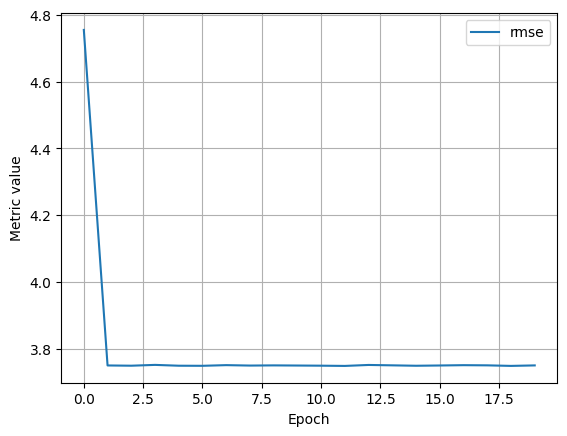

In [25]:
#updating hyperparameters
settings_2=ml_edu.experiment.ExperimentSettings(
learning_rate=0.01,
number_epochs=20,
batch_size=50,
input_features=['TRIP_MILES']
)
metrics=[keras.metrics.RootMeanSquaredError(name='rmse')]
model_2=build_model(settings_2,metrics)
experiment_2= train_model('One_feature',model_2,'FARE',settings_2,df)

ml_edu.results.plot_experiment_metrics(experiment_2,['rmse'])
ml_edu.results.plot_model_predictions(experiment_2,df,'FARE')
                                            

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 164.3919 - rmse: 12.8215
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 116.5366 - rmse: 10.7952
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 78.5151 - rmse: 8.8609
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 49.5910 - rmse: 7.0421
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 29.6667 - rmse: 5.4467
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 18.4254 - rmse: 4.2925
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 14.0719 - rmse: 3.7512
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 12.8444 - rmse: 3.5839
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 12.4539 - rmse: 3.5290
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 12.2665 - rmse: 3.5024
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 12.1816 - rmse: 3.4902
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 12.1345 - rmse: 3.48

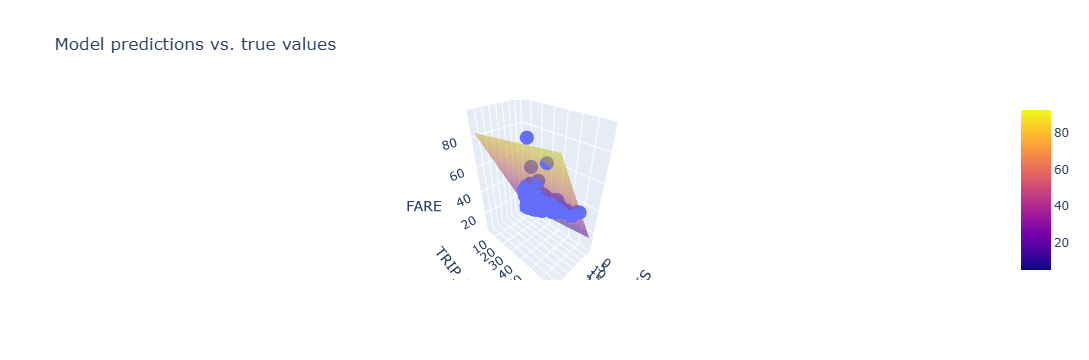

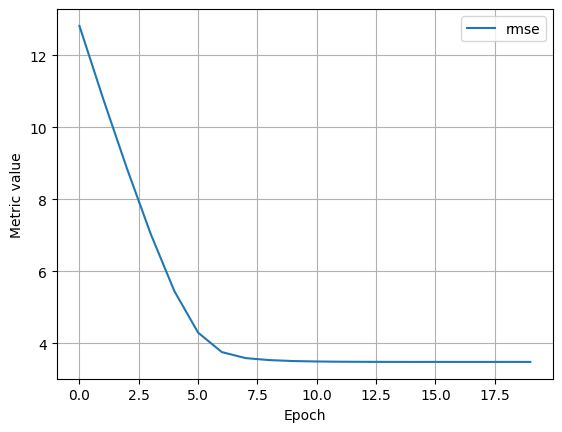

In [27]:
settings_3 = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES', 'TRIP_MINUTES']
)

df['TRIP_MINUTES'] = df['TRIP_SECONDS'] / 60

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3 = build_model(settings_3, metrics)

experiment_3 = train_model(
    'two_features',
    model_3,
    'FARE',
    settings_3,
    df
)

ml_edu.results.plot_experiment_metrics(experiment_3, ['rmse'])

ml_edu.results.plot_model_predictions(
    experiment_3,
    df,
    'FARE'
)

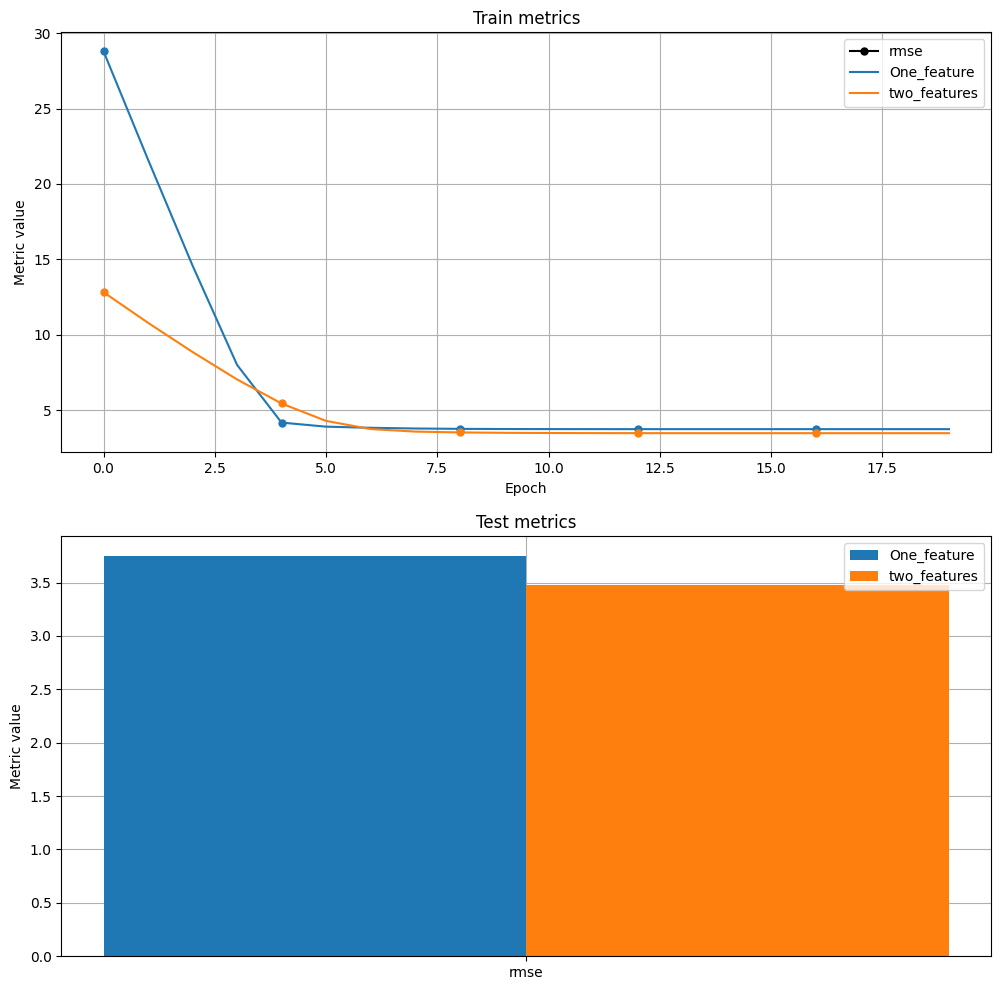

In [28]:
ml_edu.results.compare_experiment([experiment_1, experiment_3], ['rmse'], df, df['FARE'].values)

In [29]:
def format_currency(x):
  return "${:.2f}".format(x)

def build_batch(df, batch_size):
  batch = df.sample(n=batch_size).copy()
  batch.set_index(np.arange(batch_size), inplace=True)
  return batch

def predict_fare(model, df, features, label, batch_size=50):
  batch = build_batch(df, batch_size)
  predicted_values = model.predict_on_batch(x={name: batch[name].values for name in features})

  data = {"PREDICTED_FARE": [], "OBSERVED_FARE": [], "L1_LOSS": [],
          features[0]: [], features[1]: []}
  for i in range(batch_size):
    predicted = predicted_values[i][0]
    observed = batch.at[i, label]
    data["PREDICTED_FARE"].append(format_currency(predicted))
    data["OBSERVED_FARE"].append(format_currency(observed))
    data["L1_LOSS"].append(format_currency(abs(observed - predicted)))
    data[features[0]].append(batch.at[i, features[0]])
    data[features[1]].append("{:.2f}".format(batch.at[i, features[1]]))

  output_df = pd.DataFrame(data)
  return output_df

def show_predictions(output):
  header = "-" * 80
  banner = header + "\n" + "|" + "PREDICTIONS".center(78) + "|" + "\n" + header
  print(banner)
  print(output)
  return

In [30]:
output = predict_fare(experiment_3.model, df, experiment_3.settings.input_features, 'FARE')
show_predictions(output)

--------------------------------------------------------------------------------
|                                 PREDICTIONS                                  |
--------------------------------------------------------------------------------
   PREDICTED_FARE OBSERVED_FARE L1_LOSS  TRIP_MILES TRIP_MINUTES
0          $12.91        $13.00   $0.09        3.50        14.00
1          $29.58        $29.50   $0.08       11.50        17.00
2          $10.26        $10.26   $0.00        2.58         8.47
3          $18.24        $17.75   $0.49        6.11        14.18
4          $14.86        $14.50   $0.36        4.60        12.00
5          $43.48        $43.25   $0.23       17.08        35.08
6           $8.81         $8.75   $0.06        1.69        11.03
7           $7.82         $9.00   $1.18        1.51         6.63
8          $28.14        $28.00   $0.14       10.30        24.00
9           $5.36         $4.75   $0.61        0.61         2.17
10         $46.86        $45.00   $1.86   

In [31]:
git init -b main

SyntaxError: invalid syntax (1650906193.py, line 1)

In [32]:
import os
print(os.getcwd())

C:\Users\raval
